In [26]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
from palettable.colorbrewer.sequential import Oranges_9, YlGn_9
from matplotlib.patches import Patch
import contextily as cx

from lonboard import Map, PolygonLayer
from lonboard.colormap import apply_continuous_cmap

In [27]:
df = pd.read_csv("./Data/Active_Sheds2.csv")  # read csv file

In [28]:
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(
        df["Longitude Point"], df["Latitude Point"]
    ),  # extract from csv file
    crs="EPSG:4326",  # set coordinate reference system
)

gdf.to_file("sheds.fgb", driver="FlatGeobuf")  # convert to fgb file

In [29]:
census_data = gpd.read_file("sheds.fgb")

In [30]:
census_data.head()

,Job Number,Borough Name,Count Permits,First Permit Date,Current Date,Age,Permit Expiration Date,Sidewalk Shed/Linear Feet,Construction Material,Current Job Status,...,Borough Digit,Block,Lot,Applicant Business Name,ProCert,Source,activity,Commercial,CouncilDistrict,geometry
0,Q01090694-I1,Queens,NaN,8/5/2024,7/17/2026,710,10/7/2026,2170.0,NaN,Permit Entire,...,4,15610,1,MJE PROFESSIONAL SERVICES,1,DOB NOW,Local Law 11,Other Zoning Districts,31.0,POINT (-73.74192 40.59533)
1,Q01324355-I1,Queens,NaN,11/26/2025,7/17/2026,232,11/26/2026,51.0,NaN,Permit Entire,...,4,15543,35,BANGASH ASSOCIATES INC.,1,DOB NOW,Construction or Maintenance,Other Zoning Districts,31.0,POINT (-73.74978 40.60648)
2,Q01016345-I1,QUEENS,NaN,3/22/2024,7/17/2026,846,8/27/2026,82.0,NaN,Permit Entire,...,4,15557,4,MJE PROFESSIONAL SERVICES,1,DOB NOW,Construction or Maintenance,Commercial District/Overlay,31.0,POINT (-73.74998 40.60294)
3,Q00992128-I1,QUEENS,NaN,1/19/2024,7/17/2026,909,9/5/2026,50.0,NaN,Permit Entire,...,4,15560,34,ASR ENGINEERING PC,1,DOB NOW,Construction or Maintenance,Commercial District/Overlay,31.0,POINT (-73.7503 40.60266)
4,Q01420415-S1,Queens,NaN,7/15/2026,7/17/2026,1,8/31/2026,163.0,NaN,Permit Entire,...,4,15560,8,PAUL PERDEK PROF. ENG. PLLC,1,DOB NOW,Construction or Maintenance,Commercial District/Overlay,31.0,POINT (-73.75158 40.60279)


<Axes: >

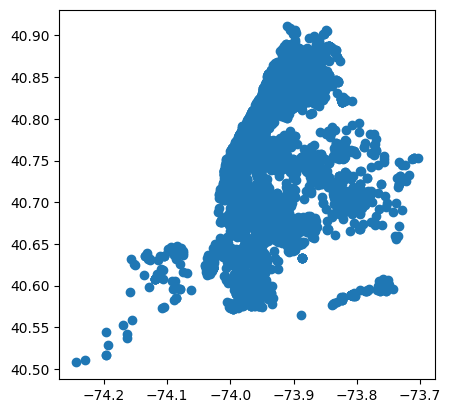

In [31]:
census_data.plot()  # first plot

<Axes: >

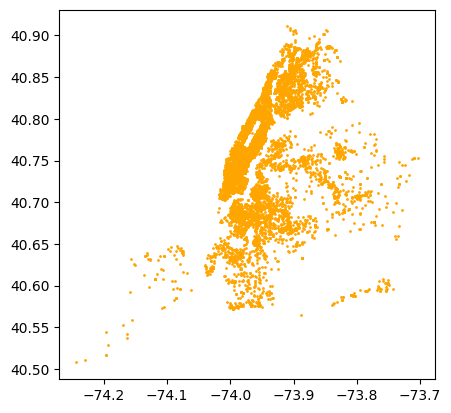

In [32]:
census_data.plot(
    markersize=1, color="orange"
)  # rescale the size of the points and change the color to orange

In [33]:
census_data.columns  # display the column names

Index(['Job Number', 'Borough Name', 'Count Permits', 'First Permit Date',
       'Current Date', 'Age', 'Permit Expiration Date',
       'Sidewalk Shed/Linear Feet', 'Construction Material',
       'Current Job Status', 'BIN Number', 'Community Board', 'Latitude Point',
       'Longitude Point', 'House Number', 'Street Name', 'Borough Digit',
       'Block', 'Lot', 'Applicant Business Name', 'ProCert', 'Source',
       'activity', 'Commercial', 'CouncilDistrict', 'geometry'],
      dtype='str')

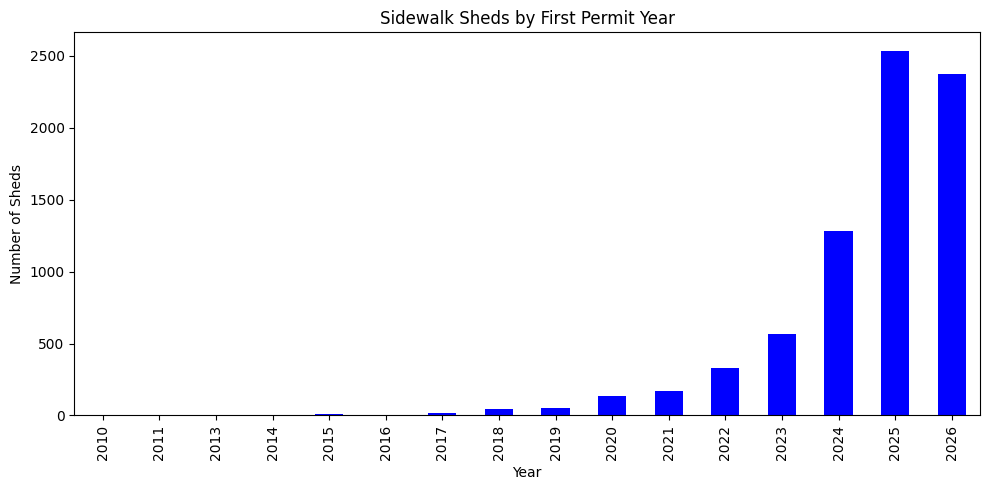

In [34]:
df["First Permit Date"] = pd.to_datetime(df["First Permit Date"], errors="coerce")
df = df.dropna(subset=["First Permit Date"])
df["Permit Year"] = df["First Permit Date"].dt.year

counts_by_year = (
    df["Permit Year"].value_counts().sort_index()
)  # count and sort the number of sheds by year

fig, ax = plt.subplots(
    figsize=(10, 5)
)  # plot as graph with x-axis as year and y-axis as number of sheds
counts_by_year.plot(kind="bar", ax=ax, color="blue")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Sheds")
ax.set_title("Sidewalk Sheds by First Permit Year")
plt.tight_layout()
plt.show()

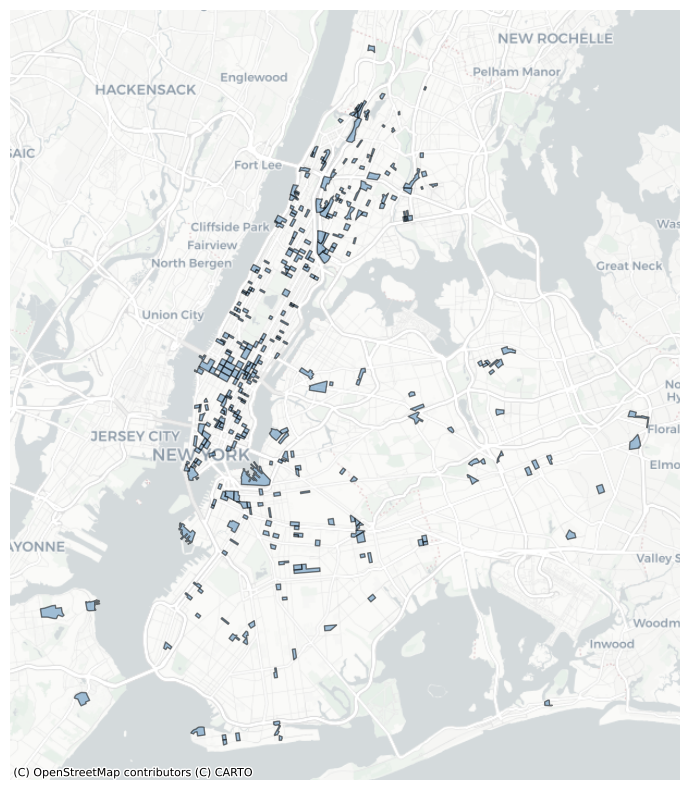

In [ ]:
df["First Permit Date"] = pd.to_datetime(df["First Permit Date"], errors="coerce")
df = df.dropna(subset=["Latitude Point", "Longitude Point", "First Permit Date"])
df = df[df["First Permit Date"].dt.year <= 2021]

# In my computational design modeling class, I am studying sidewalk sheds in New York City and the complexities surrounding them. While they are often criticized as a loophole that allows building owners to delay repairs, they have also unintentionally become an extension of public space for residents. As a next step, I want to explore their thermal qualities and potential to create comfort. At this stage, my goal is to identify and map neighborhoods with a high concentration of sidewalk sheds that have remained for more than five years.
# To Narrow my research, I am going to focus on a neighborhood with a high concentration of sidewalk sheds that have been in place for more than five years. I will use the data to identify and map these areas, which will help me understand the impact of sidewalk sheds on the urban environment and their potential to create comfort for residents.
sheds = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["Longitude Point"], df["Latitude Point"]),
    crs="EPSG:4326",
).to_crs(epsg=3857)

boundaries_path = "./Data/census_nyc_sp.fgb"
census_data = gpd.read_file(boundaries_path).to_crs(epsg=3857)
matched = gpd.sjoin(census_data, sheds, predicate="contains")
census_data = census_data[census_data.index.isin(matched.index)]

fig, ax = plt.subplots(figsize=(10, 10))
census_data.plot(ax=ax, color="steelblue", alpha=0.5, edgecolor="black", zorder=2)
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, zorder=1)
ax.set_axis_off()
plt.show()
#Shows neighborhoods with sheds in the city from 2021 or earlier

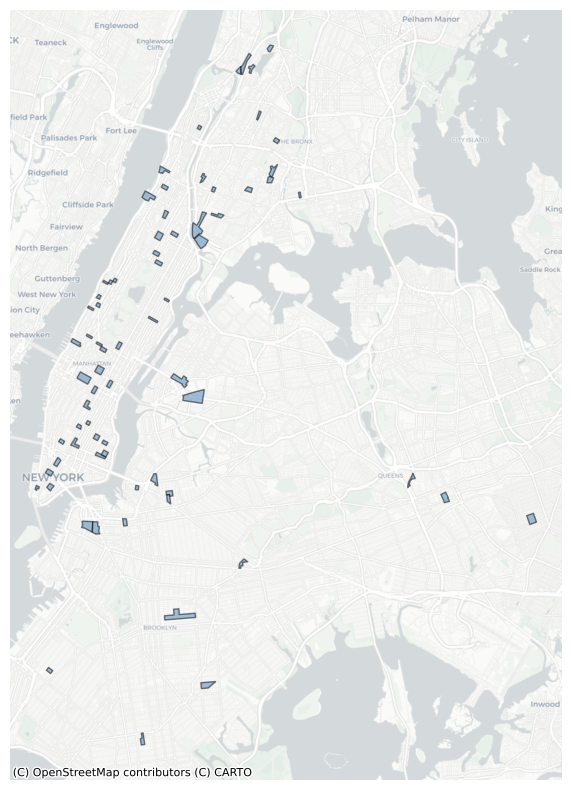

In [ ]:
df["First Permit Date"] = pd.to_datetime(df["First Permit Date"], errors="coerce")
df = df.dropna(subset=["Latitude Point", "Longitude Point", "First Permit Date"])
df = df[
    df["First Permit Date"].dt.year <= 2018
]  # neighborhoods with a high concentration of sidewalk sheds that have remained for more than 8 years.

sheds = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["Longitude Point"], df["Latitude Point"]),
    crs="EPSG:4326",
).to_crs(epsg=3857)

boundaries_path = "./Data/census_nyc_sp.fgb"
census_data = gpd.read_file(boundaries_path).to_crs(epsg=3857)
matched = gpd.sjoin(census_data, sheds, predicate="contains")
census_data = census_data[census_data.index.isin(matched.index)]

fig, ax = plt.subplots(figsize=(10, 10))
census_data.plot(ax=ax, color="steelblue", alpha=0.5, edgecolor="black", zorder=2)
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, zorder=1)
ax.set_axis_off()
plt.show()
#Shows neighborhoods with sheds in the city from 2018 or earlier